# Analysis over data preparation

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [123]:
DATASETS = {
    "ZZTo2L2Nu": {
        "path": "../CleanedDatasets/cleaned_ZZTo2L2Nu.root",
        "float_features": [
            "GenMET_pt", "MET_covXX", "MET_covXY", "MET_covYY",
            "MET_phi", "MET_pt", "MET_significance",
            "PV_x", "PV_y", "PV_z", "PV_chi2", "PV_score",
            "Electron_dxy_st", "Electron_dz_st", "Electron_eta_st",
            "Electron_mass_st", "Electron_phi_st", "Electron_pt_st",
            "Electron_dxy_nd", "Electron_dz_nd", "Electron_eta_nd",
            "Electron_mass_nd", "Electron_phi_nd", "Electron_pt_nd",
            "Muon_dxy_st", "Muon_dz_st", "Muon_eta_st",
            "Muon_mass_st", "Muon_phi_st", "Muon_pt_st",
            "Muon_dxy_nd", "Muon_dz_nd", "Muon_eta_nd",
            "Muon_mass_nd", "Muon_phi_nd", "Muon_pt_nd"
        ],
        "int_features": [
            "nElectron", "nMuon", "nSV",
            "Electron_charge_st", "Electron_charge_nd",
            "Muon_charge_st", "Muon_charge_nd"
        ]
    },
    "HToAATo2Mu2B": {
        "path": "../CleanedDatasets/cleaned_HToAATo2Mu2B.root",
        "float_features": [
            "GenMET_pt", "MET_covXX", "MET_covXY", "MET_covYY",
            "MET_phi", "MET_pt", "MET_significance", "fixedGridRhoFastjetAll",
            "PV_x", "PV_y", "PV_z", "PV_chi2", "PV_score",
            "Jet_eta_bst", "Jet_pt_bst", "Jet_phi_bst", "Jet_mass_bst",
            "Jet_area_bst", "Jet_btag_bst", "Jet_rawFactor_bst",
            "Jet_chHEF_bst", "Jet_neHEF_bst", "Jet_chEmEF_bst", "Jet_neEmEF_bst", "Jet_muEF_bst",
            "Jet_eta_bnd", "Jet_pt_bnd", "Jet_phi_bnd", "Jet_mass_bnd",
            "Jet_area_bnd", "Jet_btag_bnd", "Jet_rawFactor_bnd",
            "Jet_chHEF_bnd", "Jet_neHEF_bnd", "Jet_chEmEF_bnd", "Jet_neEmEF_bnd", "Jet_muEF_bnd",
            "Muon_dxy_st", "Muon_dz_st", "Muon_eta_st",
            "Muon_mass_st", "Muon_phi_st", "Muon_pt_st",
            "Muon_dxy_nd", "Muon_dz_nd", "Muon_eta_nd",
            "Muon_mass_nd", "Muon_phi_nd", "Muon_pt_nd",
            "SV_dlenSig_bst", "SV_mass_bst", "M_mumu", "M_bb", "M_mumu_bb",
            "dR_MET_bb", "MET_projection_par", "MET_projection_perp",
            "dPhi_MET_mu1", "dPhi_MET_jet1", "HT"
        ],
        "int_features": [
            "nJet", "nMuon", "nSV", "nGenJet",
            "Muon_charge_st", "Muon_charge_nd"
        ]
    }
}

TREE_NAME = "Events"

PALETTE = ["royalblue", "olivedrab", "orangered"]

In [124]:
def _load_dataset(FLOAT_FEATURES, INT_FEATURES, path, tree_name):
    """
        Loads branches from a .root file and returns a Pandas DataFrame.
    """
    all_branches = FLOAT_FEATURES + INT_FEATURES
    with uproot.open(f"{path}:{tree_name}") as tree:
        df = tree.arrays(all_branches, library="pd")

    # Explicit casting
    df[FLOAT_FEATURES] = df[FLOAT_FEATURES].astype(np.float64)
    df[INT_FEATURES]   = df[INT_FEATURES].astype(np.int64)
    return df

In [125]:
def _correlation_heatmap(df, FLOAT_FEATURES, label):
    corr = df[FLOAT_FEATURES].replace([np.inf, -np.inf], np.nan).corr()

    print("\nCouples of features with correlation > 0.70:")
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i):
            corr_value = corr.iloc[i, j]
            if abs(corr_value) > 0.70:
                feat1 = corr.columns[i]
                feat2 = corr.columns[j]
                high_corr.append((feat1, feat2, corr_value))
                print(f"{feat1}, {feat2} = {corr_value:.2f}")

    n = len(corr)

    fig_size  = max(14, n * 0.45)
    font_size = max(5, min(8, 250 // n))

    fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.9))
    sns.heatmap(
        corr,
        annot=True, fmt=".2f",
        cmap="coolwarm", linewidths=0.3, linecolor="gray",
        annot_kws={"size": font_size},
        ax=ax
    )
    ax.set_title(f"Correlation Heatmap — {label}", fontsize=12, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=45, labelsize=font_size+1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=font_size+1)
    ax.tick_params(axis="y", rotation=0,  labelsize=font_size+1)
    fig.tight_layout()
    plt.show()
    return

In [126]:
def _scatterplot_MET(df, label, color):
    x = df["MET_pt"]
    y = df["GenMET_pt"]
    mask = np.isfinite(x) & np.isfinite(y)

    # Statistics
    print(f"Statistics for dataset {label}:")
    print(f"    Mean MET_pt: {x.mean()}, Median MET_pt: {x.median()}")
    print(f"    Mean GenMET_pt: {y.mean()}, Median GenMET_pt: {y.median()}")

    plt.figure(figsize=(10, 8))
    plt.scatter(
        x[mask], y[mask], s=4, alpha=0.35,
        color=color, label=label, rasterized=True)

    # y = x line
    lim_max = plt.xlim()[1]
    lim = [0, lim_max]
    plt.plot(lim, lim, "k--", lw=1, label="y = x")

    plt.title(f"GenMET vs MET - {label}", fontsize=13, fontweight="bold")
    plt.xlabel("MET_pt [GeV]", fontsize=11)
    plt.ylabel("GenMET_pt [GeV]", fontsize=11)
    plt.legend(markerscale=3, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.plot()
    return

In [127]:
def _data_distributions(df, FLOAT_FEATURES, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(vals, bins=100, density=True, histtype="step",
                linewidth=1.5, color=color, label=label)
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Density", fontsize=8)
        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Distributions for float features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [128]:
def _boxplots(df, FLOAT_FEATURES, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    print(f"Outliers — {label}")

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()

        # IQR
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = q3 - q1
        lower, upper = q1 - 1.5 * IQR, q3 + 1.5 * IQR
        n_outliers = ((vals < lower) | (vals > upper)).sum()
        pct = n_outliers / len(vals) * 100
        print(f"  {feat:<20} {n_outliers:>6} outliers ({pct:.2f}%)")

        bp = ax.boxplot(vals, patch_artist=True, vert=True,
                        flierprops=dict(marker=".", markersize=2, alpha=0.3,
                                        markerfacecolor=color, markeredgecolor=color),
                        medianprops=dict(color="black", linewidth=1.5),
                        boxprops=dict(facecolor=color, alpha=0.5),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color))

        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.set_ylabel(feat, fontsize=8)
        ax.set_xticks([])
        ax.text(0.97, 0.97, f"{n_outliers} outliers\n({pct:.1f}%)",
                transform=ax.transAxes, fontsize=7,
                verticalalignment="top", horizontalalignment="right",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
        ax.grid(axis="y", alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Boxplots — {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [129]:
def _draw_bar(ax, df, feat, color, label):
    vals = df[feat].dropna()
    bins = np.arange(int(vals.min()), int(vals.max()) + 2) - 0.5
    centers = (bins[:-1] + bins[1:]) / 2
    counts, _ = np.histogram(vals, bins=bins)
    ax.bar(centers, counts, width=0.8, color=color, label=label, alpha=0.85)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    return

def _data_barplots(df, INT_FEATURES, label, color):
    n_feat = len(INT_FEATURES)
    ncols = 2
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten()

    for idx, feat in enumerate(INT_FEATURES):
        _draw_bar(axes[idx], df, feat, color, label)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Barplots for integer features — {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [130]:
def _nJet_vs_nGenJet(df, label, color):
    fig, ax = plt.subplots(figsize=(7, 5))

    all_jet = pd.concat([df["nJet"], df["nGenJet"]]).dropna()
    bins = np.arange(int(all_jet.min()), int(all_jet.max()) + 2) - 0.5
    centers = (bins[:-1] + bins[1:]) / 2
    width = 0.8 / 2

    for i, (feat, hatch, alpha) in enumerate([("nJet", "", 0.75), ("nGenJet", "//", 0.45)]):
        counts, _ = np.histogram(df[feat].dropna(), bins=bins)
        offset = (i - 1 + 0.5) * width
        ax.bar(centers + offset, counts, width=width * 0.9,
               color=color, alpha=alpha, hatch=hatch,
               edgecolor="grey", linewidth=0.4,
               label=f"{label} — {feat}")

    ax.set_xticks(np.arange(int(all_jet.min()), int(all_jet.max()) + 1))
    ax.set_xlabel("n", fontsize=10)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_title(f"nJet vs nGenJet — {label}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()
    return

---

## ZZTo2L2Nu dataset


In [131]:
label = "ZZTo2L2Nu"
entry = DATASETS[label]

FLOAT_FEATURES_ZZTo2L2Nu = entry["float_features"]
INT_FEATURES_ZZTo2L2Nu = entry["int_features"]
color = PALETTE[0]

df = _load_dataset(FLOAT_FEATURES_ZZTo2L2Nu, INT_FEATURES_ZZTo2L2Nu, entry["path"], TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")
print(f"    Number of float features: {len(FLOAT_FEATURES_ZZTo2L2Nu)}")
print(f"    Number of int features:   {len(INT_FEATURES_ZZTo2L2Nu)}")

Dataset ZZTo2L2Nu:
    43 features x 49727 events
    Number of float features: 36
    Number of int features:   7



Couples of features with correlation > 0.70:
MET_covYY, MET_covXX = 0.91
MET_pt, GenMET_pt = 0.93
Electron_pt_nd, Electron_pt_st = 0.74
Muon_mass_st, Electron_pt_st = -0.72
Muon_mass_st, Electron_pt_nd = -0.73
Muon_mass_nd, Electron_pt_st = -0.72
Muon_mass_nd, Electron_pt_nd = -0.73
Muon_mass_nd, Muon_mass_st = 1.00


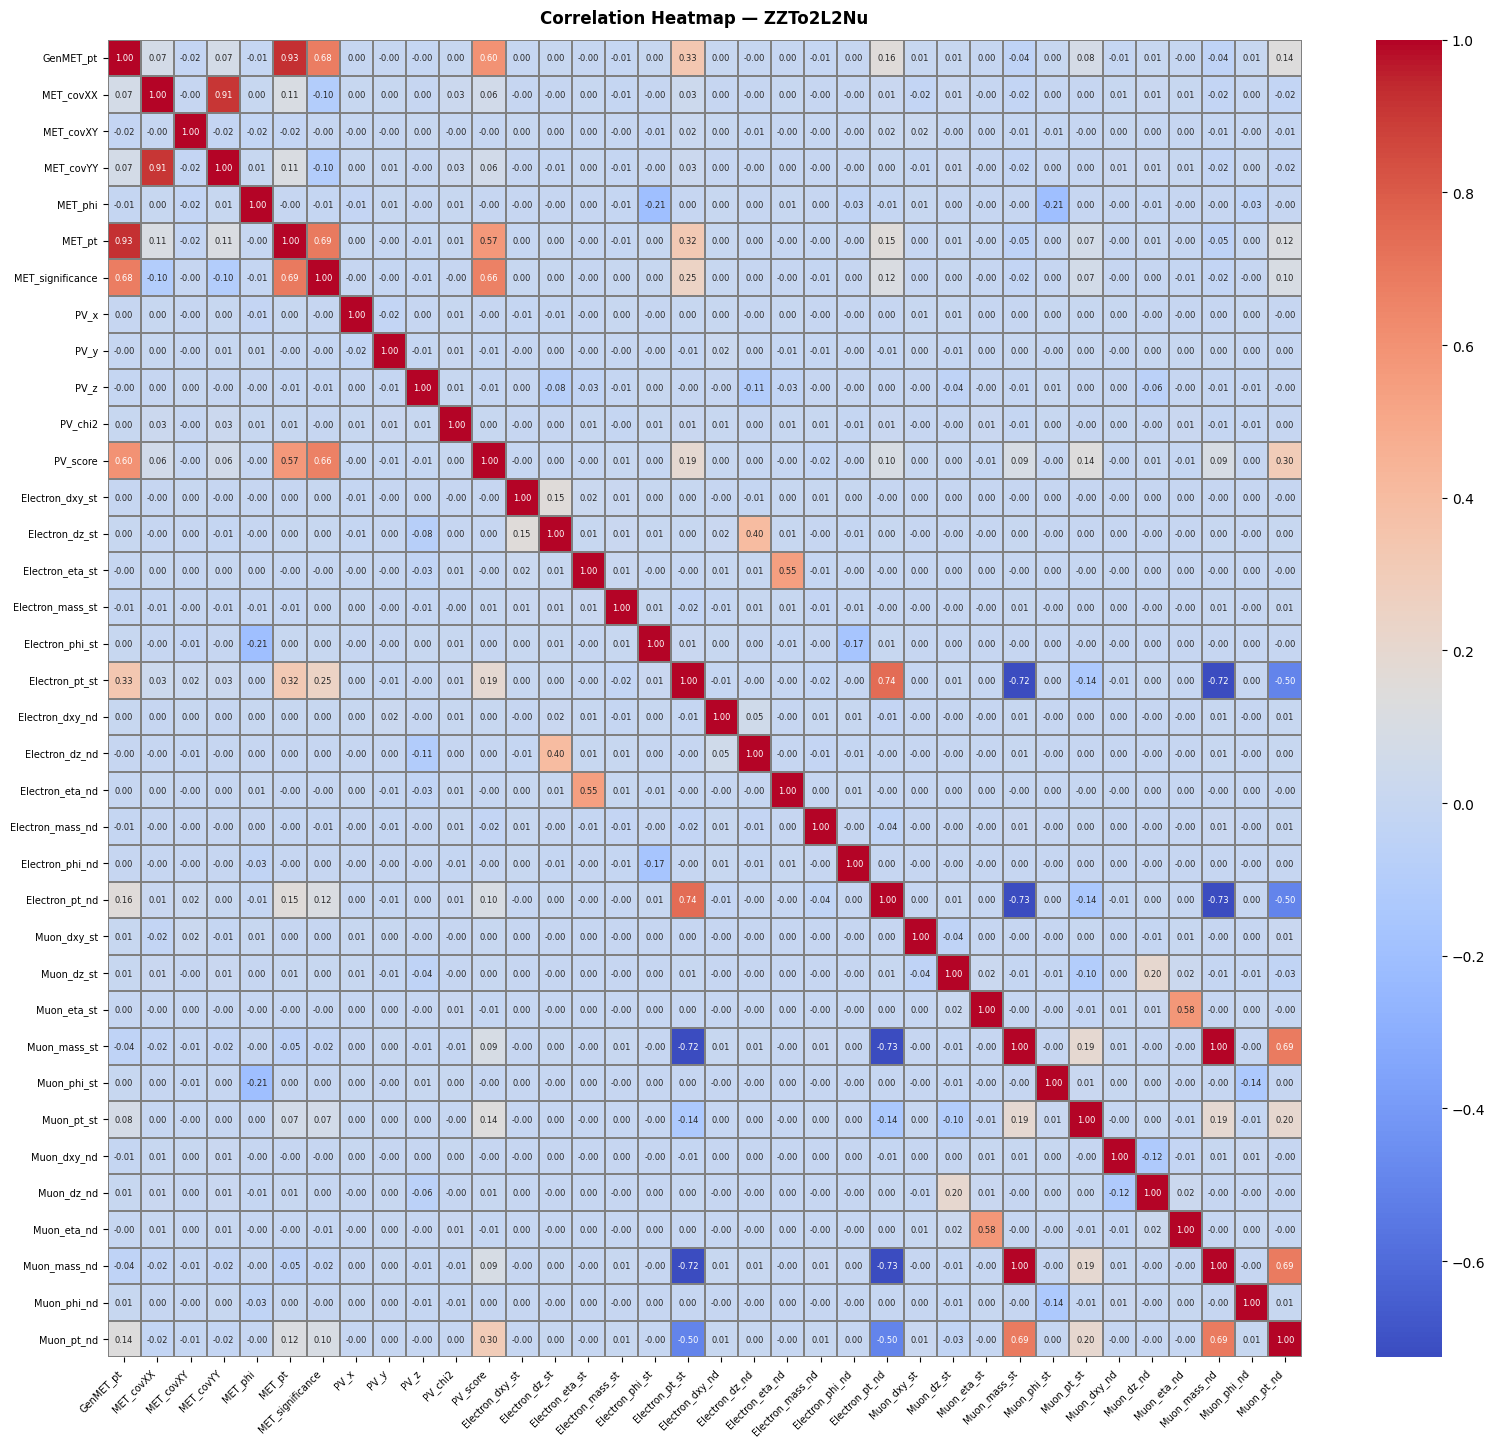

In [132]:
_correlation_heatmap(df, FLOAT_FEATURES_ZZTo2L2Nu, label)

In [133]:
print(df[["GenMET_pt", "MET_pt"]].describe())

          GenMET_pt        MET_pt
count  49727.000000  49727.000000
mean      58.470142     64.447550
std       51.067363     51.501383
min        0.024750      0.134062
25%       25.890625     31.187620
50%       45.281250     51.866199
75%       74.500000     82.141964
max      955.000000    993.224548


Statistics for dataset ZZTo2L2Nu:
    Mean MET_pt: 64.44754987161176, Median MET_pt: 51.8661994934082
    Mean GenMET_pt: 58.47014196475157, Median GenMET_pt: 45.28125


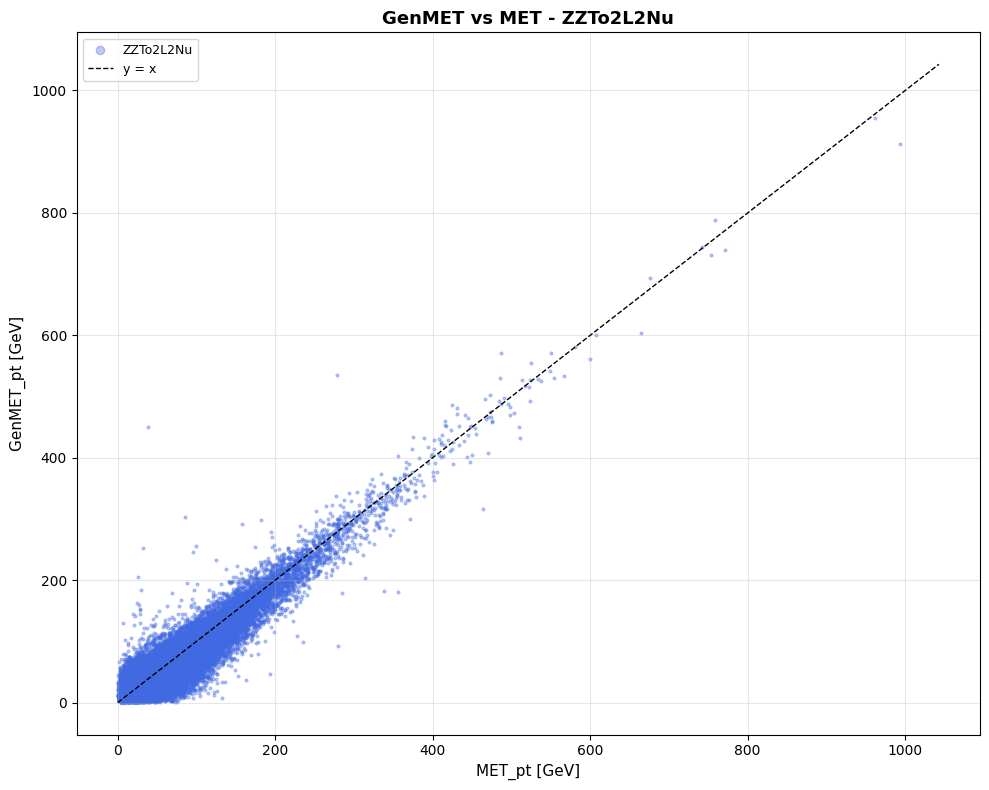

In [134]:
_scatterplot_MET(df, label=label, color=color)

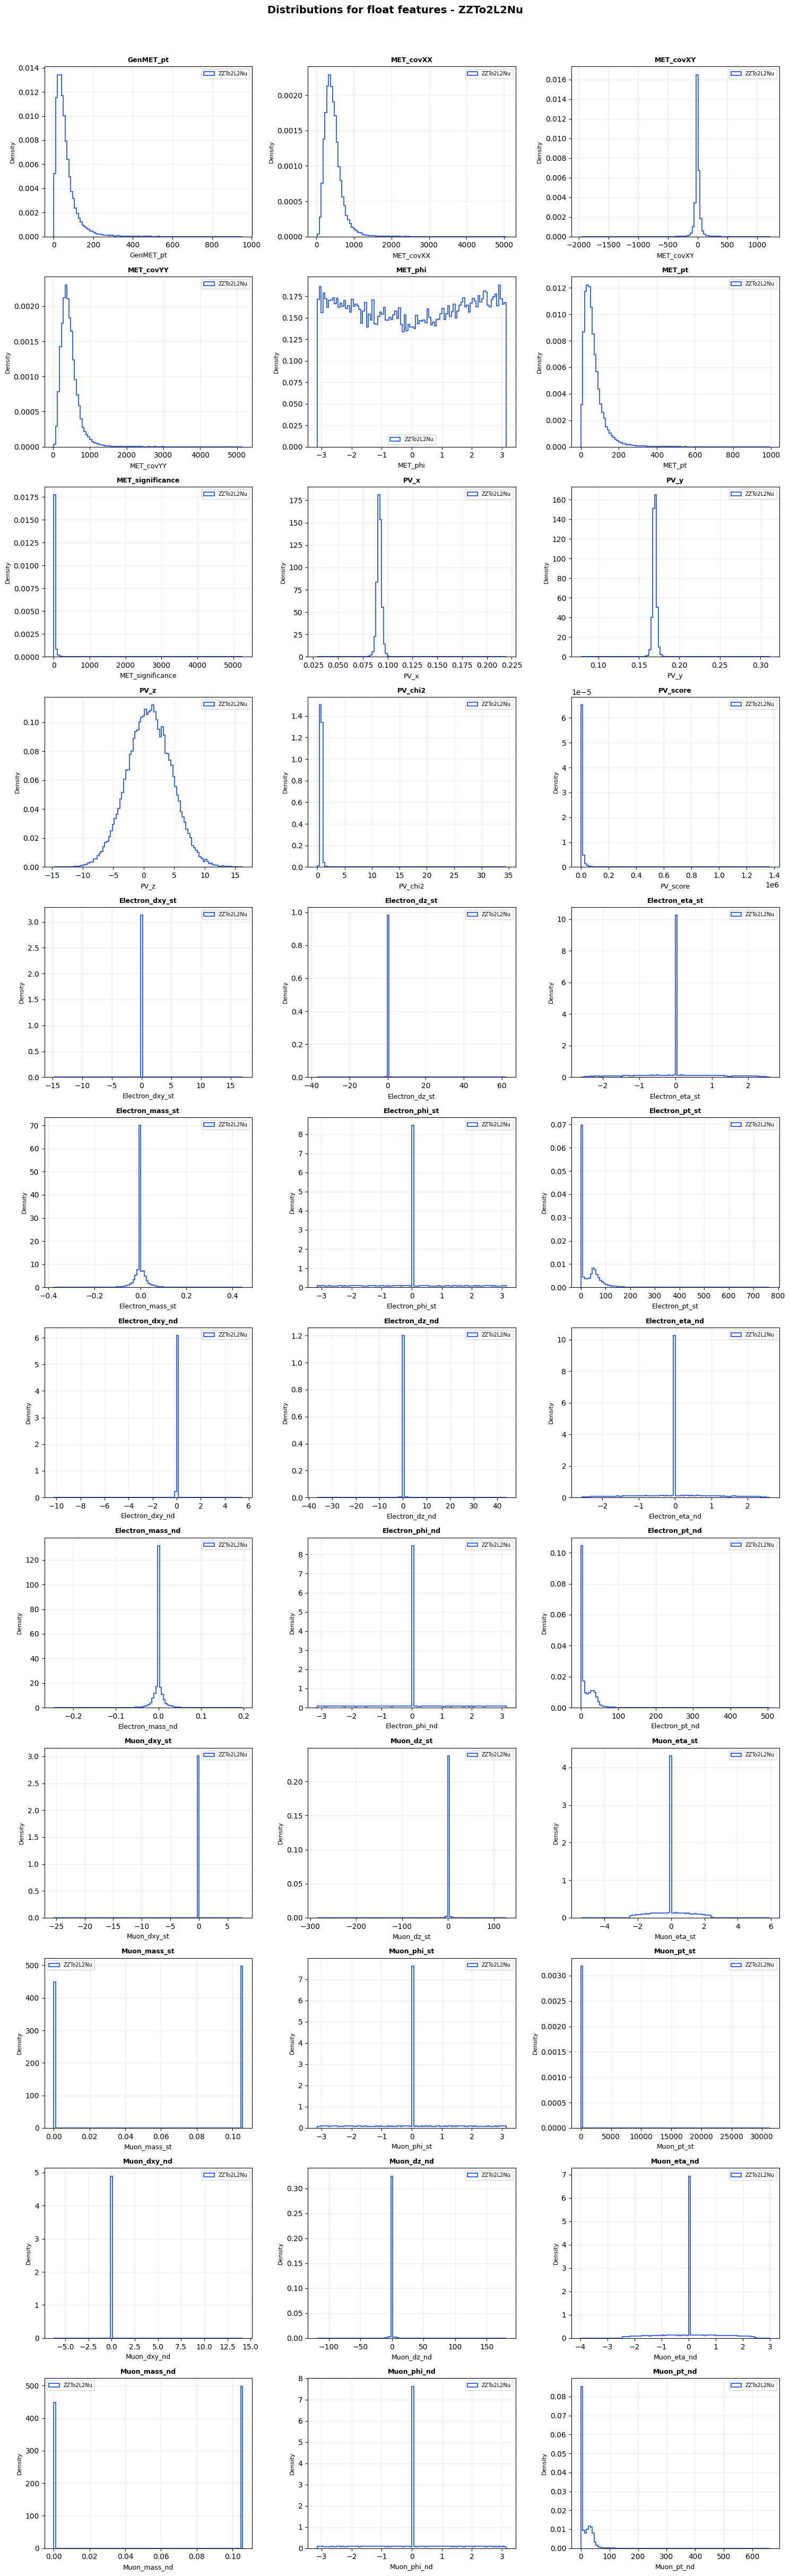

In [135]:
_data_distributions(df, FLOAT_FEATURES_ZZTo2L2Nu, label, color)

Outliers — ZZTo2L2Nu
  GenMET_pt              2722 outliers (5.47%)
  MET_covXX              1736 outliers (3.49%)
  MET_covXY              5930 outliers (11.93%)
  MET_covYY              1725 outliers (3.47%)
  MET_phi                   0 outliers (0.00%)
  MET_pt                 2469 outliers (4.97%)
  MET_significance       5014 outliers (10.08%)
  PV_x                   1606 outliers (3.23%)
  PV_y                   1607 outliers (3.23%)
  PV_z                    337 outliers (0.68%)
  PV_chi2                1609 outliers (3.24%)
  PV_score               4798 outliers (9.65%)
  Electron_dxy_st       23562 outliers (47.38%)
  Electron_dz_st        23562 outliers (47.38%)
  Electron_eta_st       23562 outliers (47.38%)
  Electron_mass_st      23562 outliers (47.38%)
  Electron_phi_st       23562 outliers (47.38%)
  Electron_pt_st         1189 outliers (2.39%)
  Electron_dxy_nd       23562 outliers (47.38%)
  Electron_dz_nd        23562 outliers (47.38%)
  Electron_eta_nd       23562 

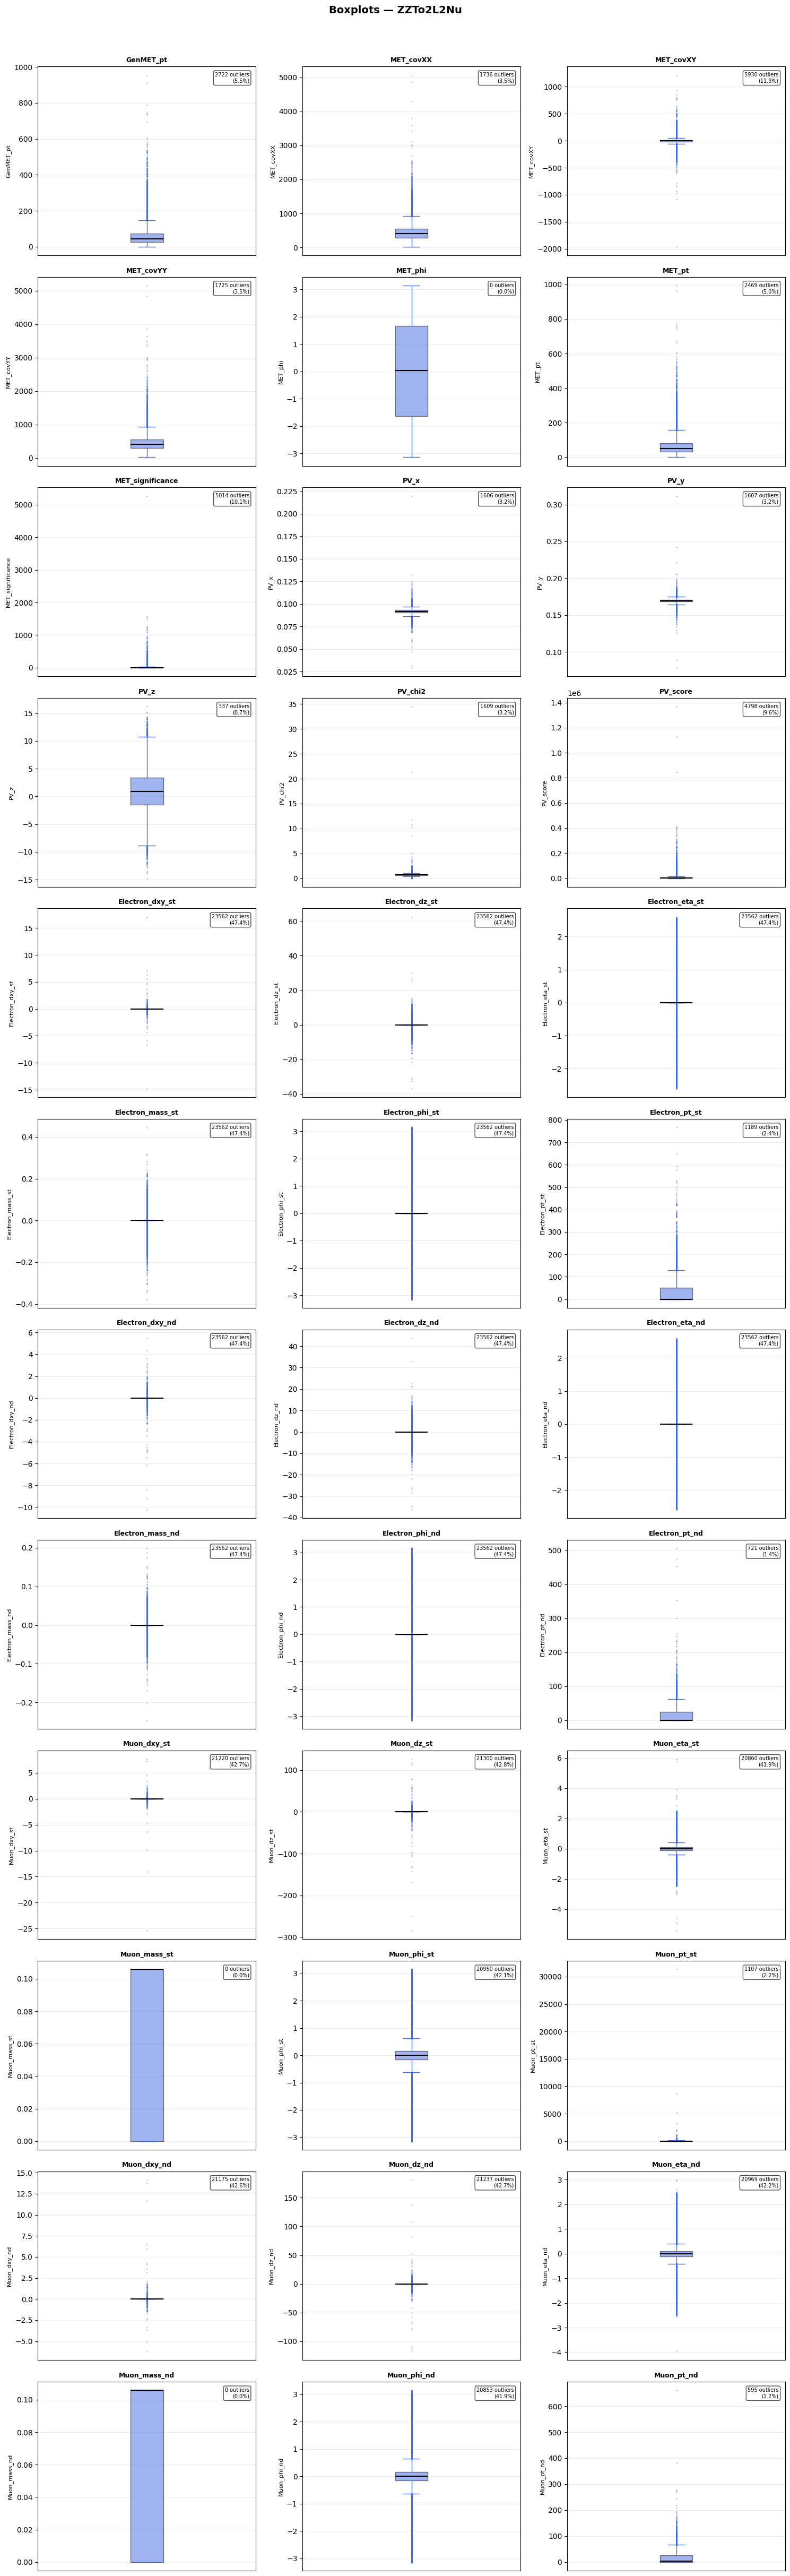

In [136]:
_boxplots(df, FLOAT_FEATURES_ZZTo2L2Nu, label, color)

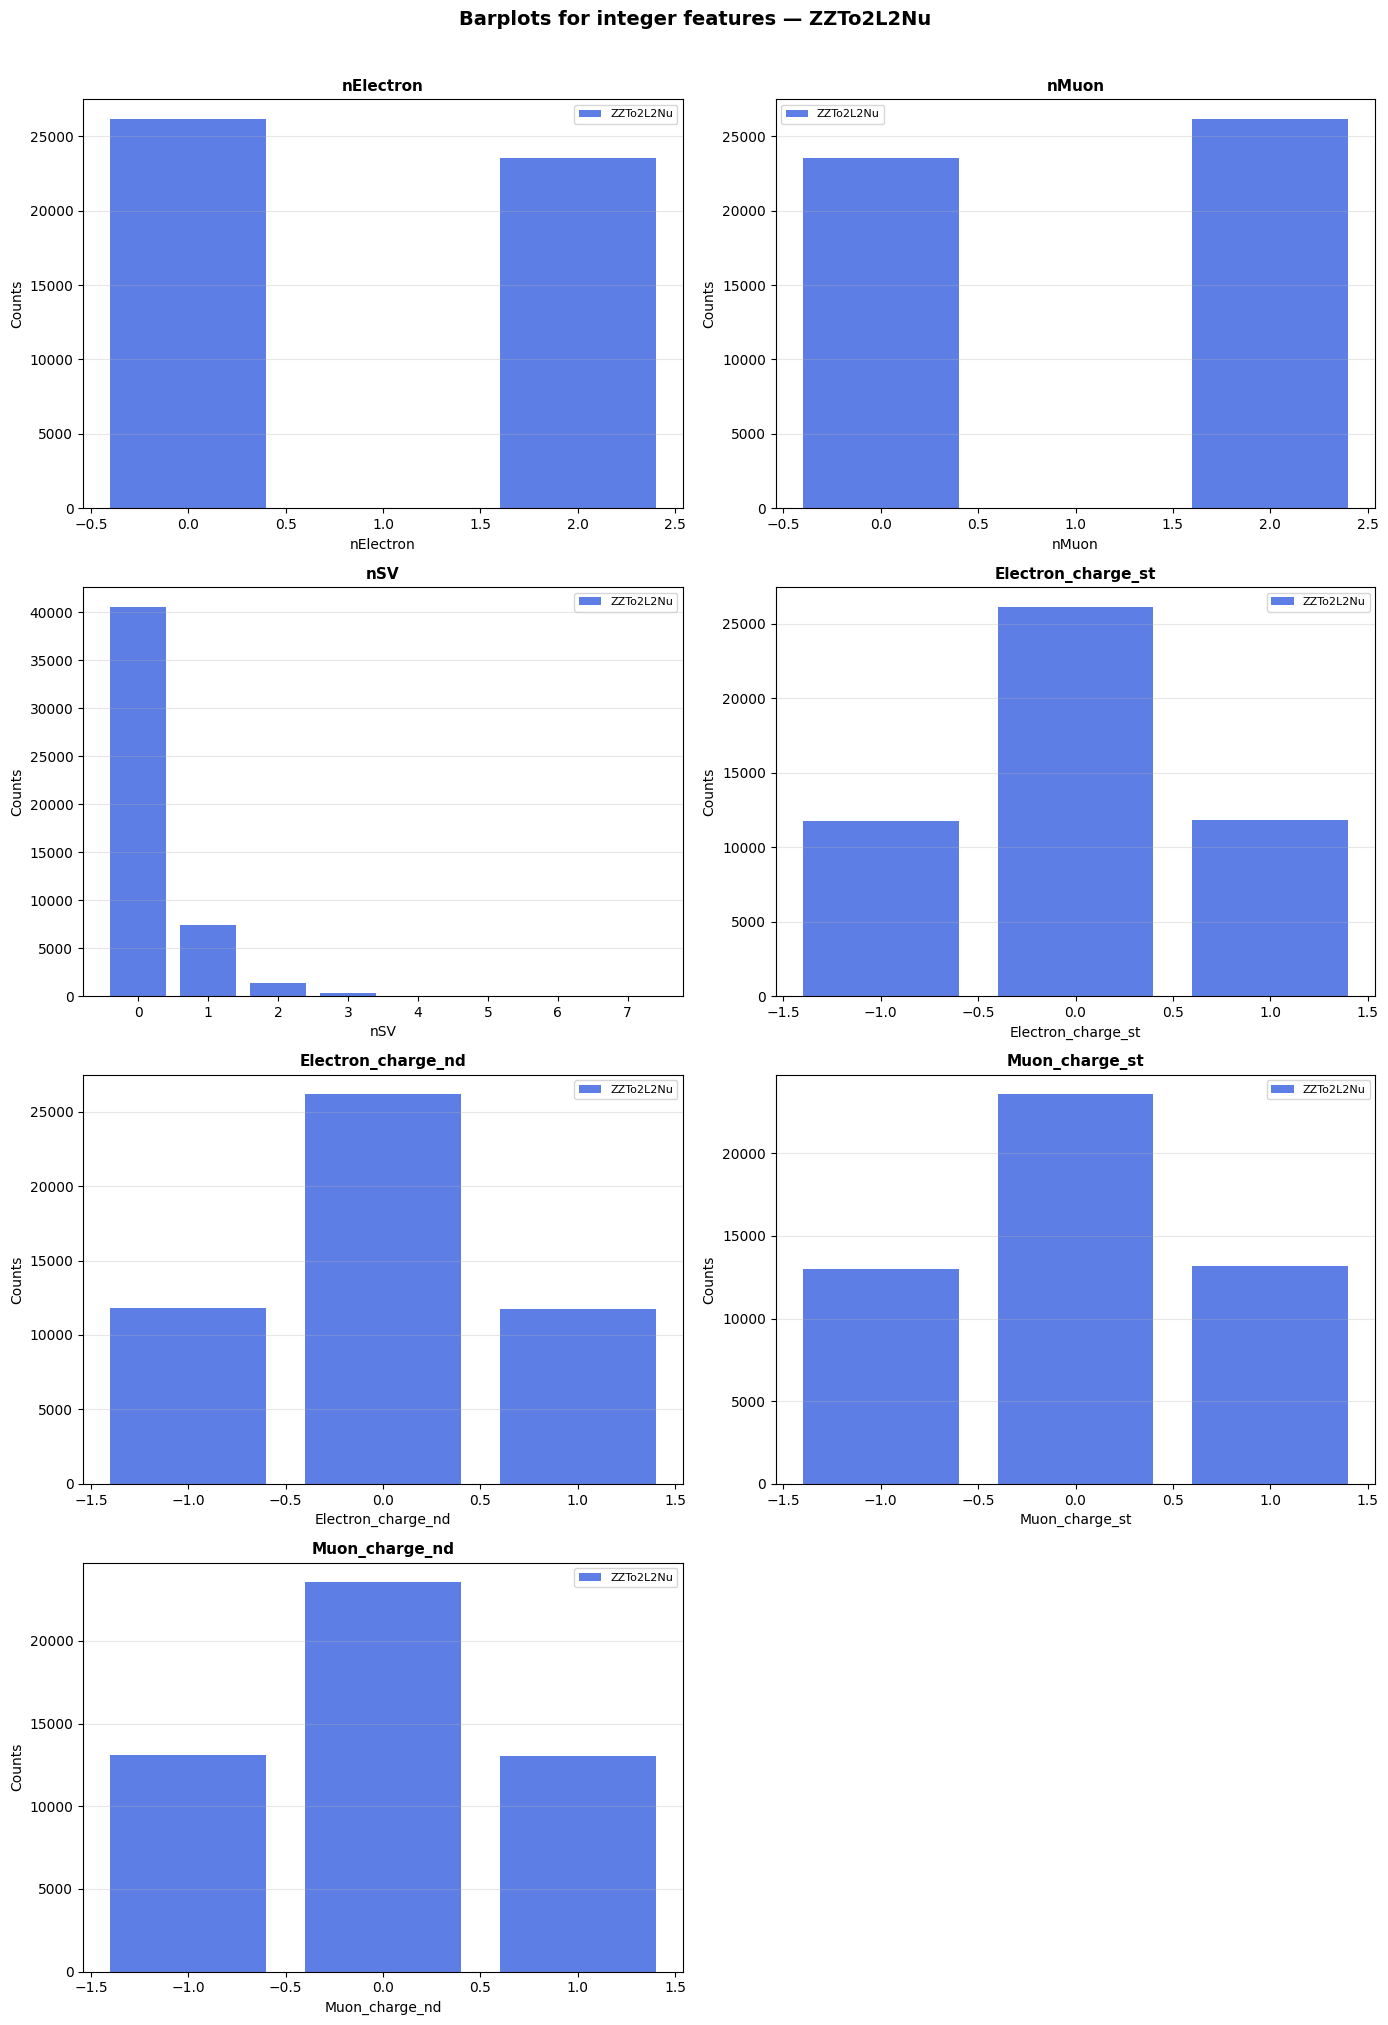

In [137]:
_data_barplots(df, INT_FEATURES_ZZTo2L2Nu, label, color)

Due to curse of dimensionality, we remove features that are uninteresting for our specific purpose or that proved to be redundant in the correlation analysis.

In [138]:
DROP_ZZTo2L2Nu = [
    "PV_x", "PV_y",
    "MET_phi", "MET_covYY",
    "Electron_mass_st", "Electron_mass_nd",
    "Muon_mass_st", "Muon_mass_nd"
]

df = df.drop(columns=DROP_ZZTo2L2Nu)
print(f"Shape of ZZTo2L2Nu after preparation: {df.shape[1]} features x {df.shape[0]} events")
print(f"Remaining features of ZZTo2L2Nu after preparation: {list(df.columns)}")

df.to_parquet("../CleanedDatasets/ZZTo2L2Nu.parquet", index=False)

Shape of ZZTo2L2Nu after preparation: 35 features x 49727 events
Remaining features of ZZTo2L2Nu after preparation: ['GenMET_pt', 'MET_covXX', 'MET_covXY', 'MET_pt', 'MET_significance', 'PV_z', 'PV_chi2', 'PV_score', 'Electron_dxy_st', 'Electron_dz_st', 'Electron_eta_st', 'Electron_phi_st', 'Electron_pt_st', 'Electron_dxy_nd', 'Electron_dz_nd', 'Electron_eta_nd', 'Electron_phi_nd', 'Electron_pt_nd', 'Muon_dxy_st', 'Muon_dz_st', 'Muon_eta_st', 'Muon_phi_st', 'Muon_pt_st', 'Muon_dxy_nd', 'Muon_dz_nd', 'Muon_eta_nd', 'Muon_phi_nd', 'Muon_pt_nd', 'nElectron', 'nMuon', 'nSV', 'Electron_charge_st', 'Electron_charge_nd', 'Muon_charge_st', 'Muon_charge_nd']


---

## HToAATo2Mu2B dataset

In [139]:
label = "HToAATo2Mu2B"
entry = DATASETS[label]

FLOAT_FEATURES_HToAATo2Mu2B = entry["float_features"]
INT_FEATURES_HToAATo2Mu2B = entry["int_features"]
color = PALETTE[2]

df = _load_dataset(FLOAT_FEATURES_HToAATo2Mu2B, INT_FEATURES_HToAATo2Mu2B, entry["path"], TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")
print(f"    Number of float features: {len(FLOAT_FEATURES_HToAATo2Mu2B)}")
print(f"    Number of int features:   {len(INT_FEATURES_HToAATo2Mu2B)}")

Dataset HToAATo2Mu2B:
    66 features x 2530 events
    Number of float features: 60
    Number of int features:   6



Couples of features with correlation > 0.70:
MET_covYY, MET_covXX = 0.87
MET_significance, MET_pt = 0.78
fixedGridRhoFastjetAll, MET_covXX = 0.71
fixedGridRhoFastjetAll, MET_covYY = 0.73
PV_y, PV_x = -0.79
Jet_mass_bst, Jet_pt_bst = 0.87
Jet_mass_bnd, Jet_pt_bnd = 0.83
HT, Jet_pt_bst = 0.70


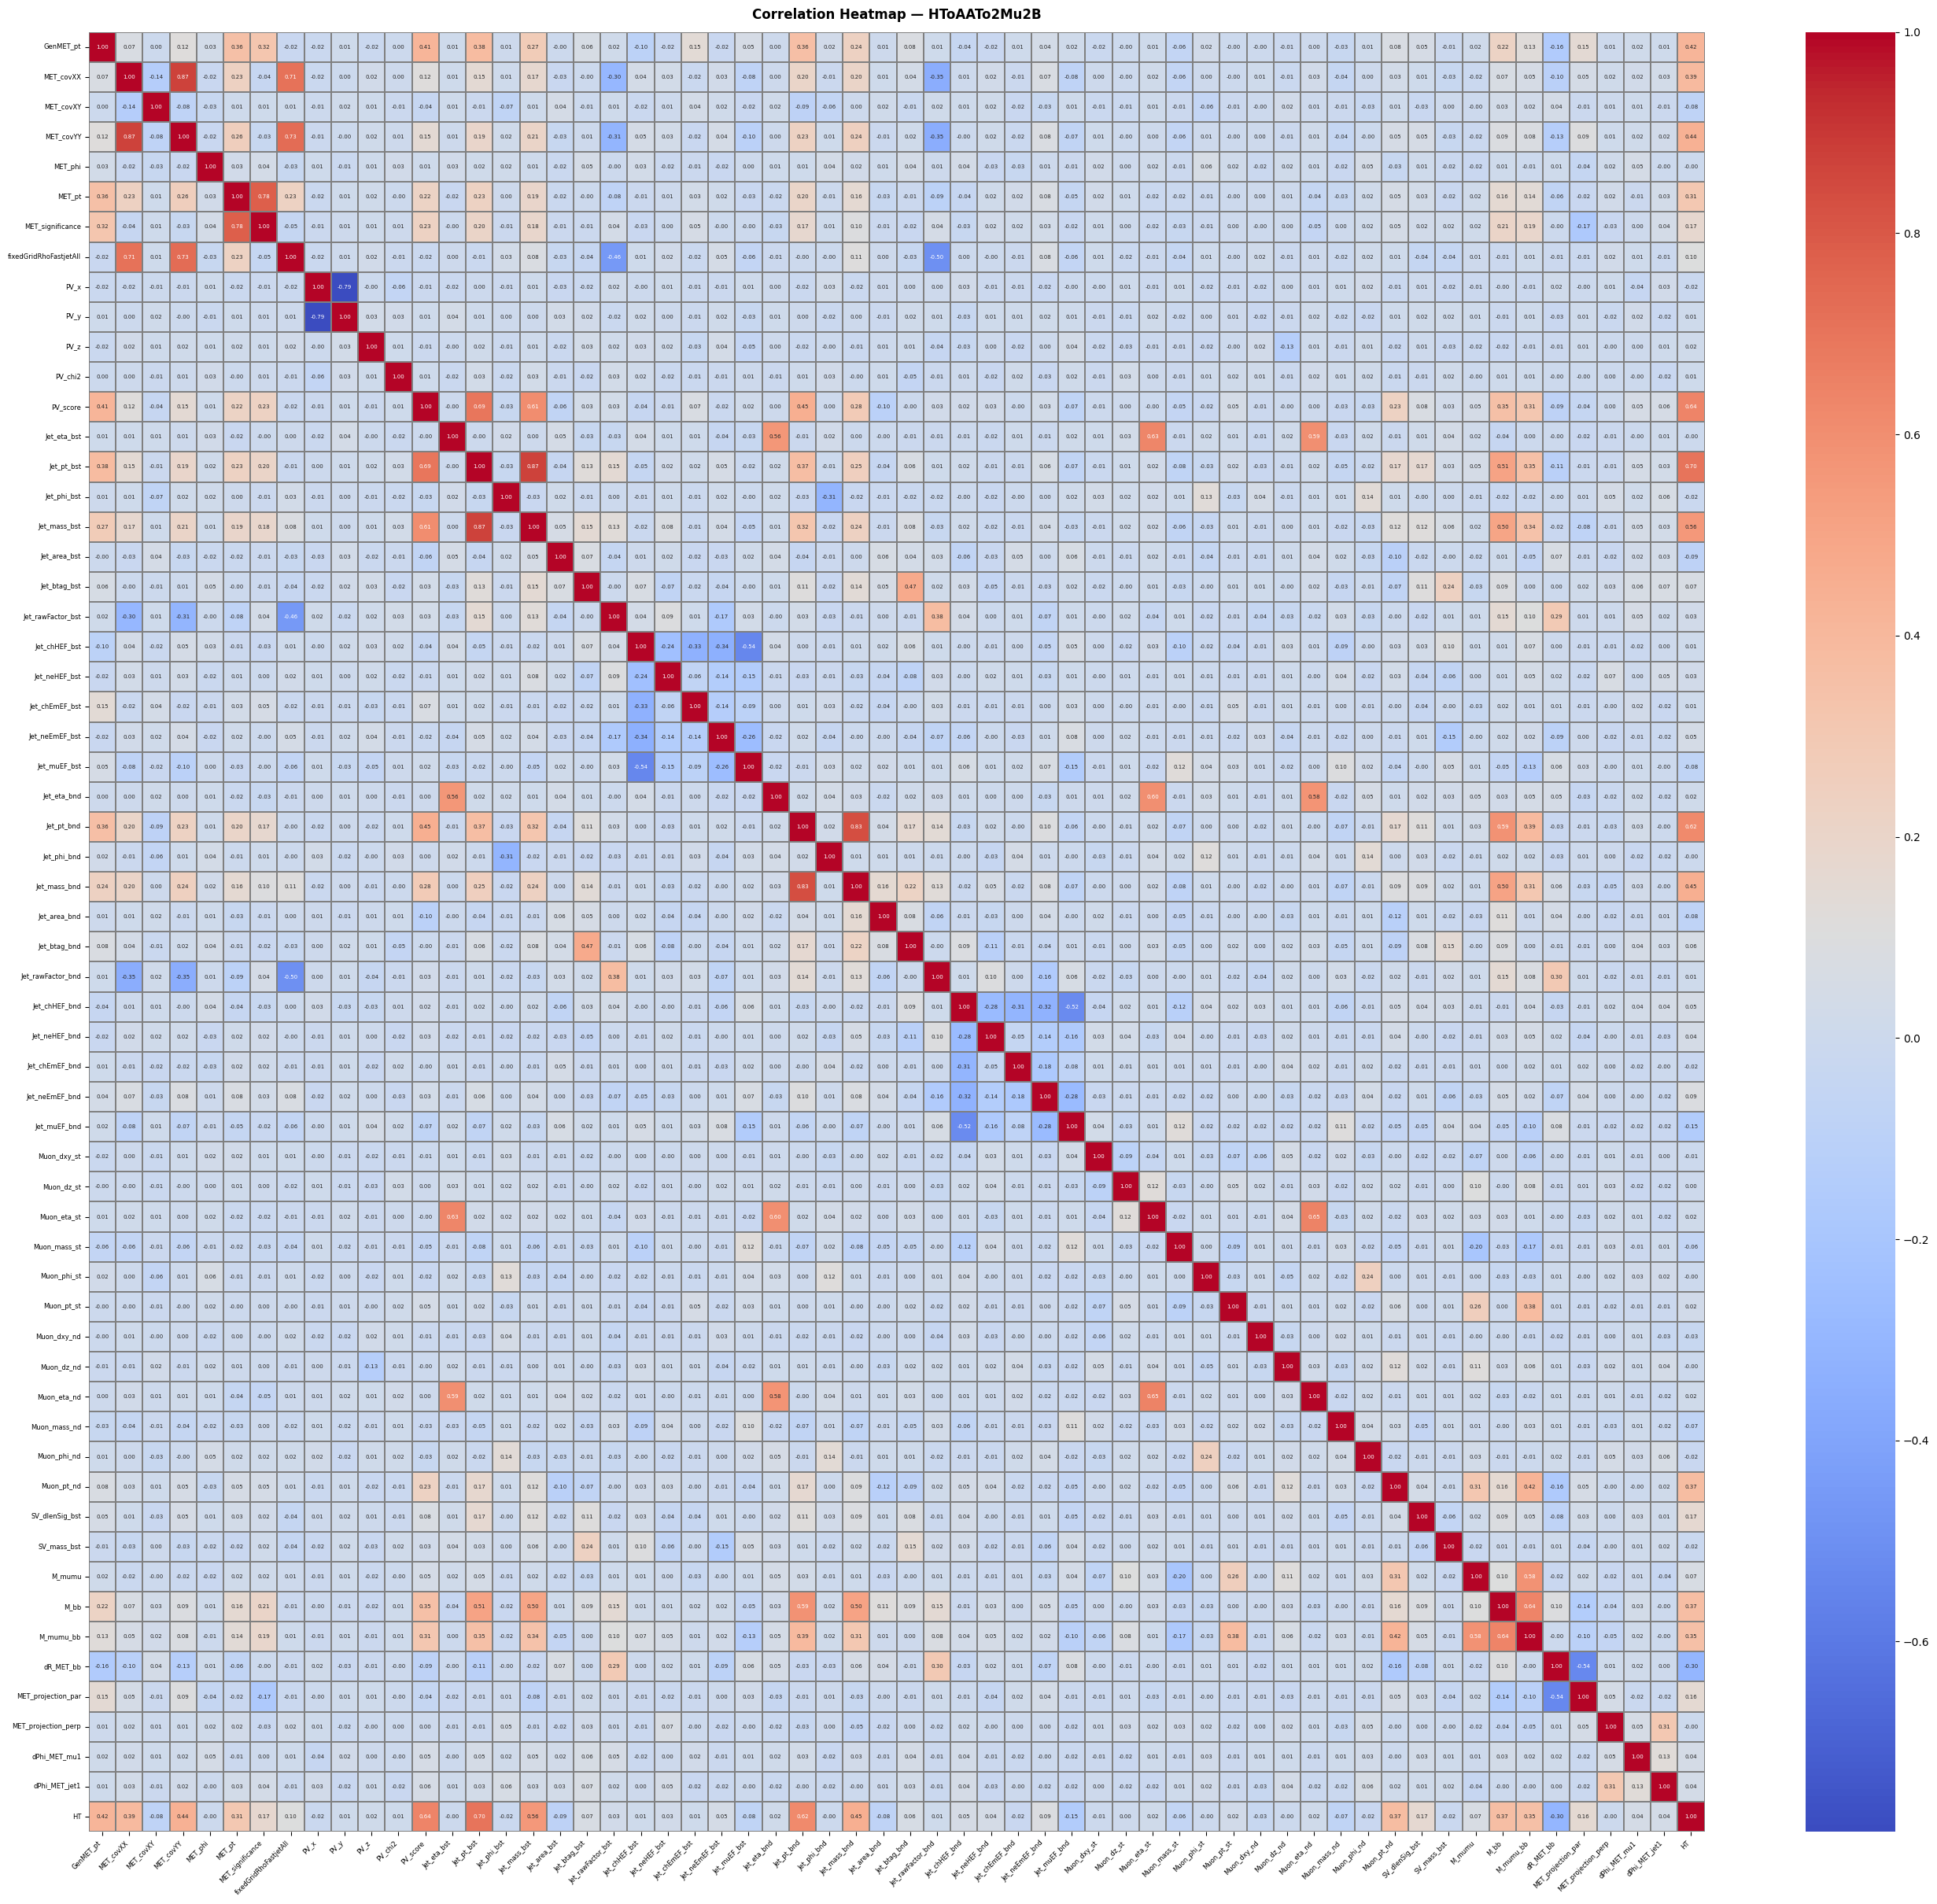

In [140]:
_correlation_heatmap(df, FLOAT_FEATURES_HToAATo2Mu2B, label)

In [141]:
print(df[["GenMET_pt", "MET_pt"]].describe())

          GenMET_pt       MET_pt
count  2.530000e+03  2530.000000
mean   9.824980e+00    29.102447
std    1.191774e+01    18.382373
min    5.190515e-12     0.299005
25%    3.321777e+00    16.288501
50%    6.962891e+00    25.961512
75%    1.282422e+01    38.377234
max    2.945000e+02   248.739197


Statistics for dataset HToAATo2Mu2B:
    Mean MET_pt: 29.102447026520377, Median MET_pt: 25.961511611938477
    Mean GenMET_pt: 9.824980218643844, Median GenMET_pt: 6.962890625


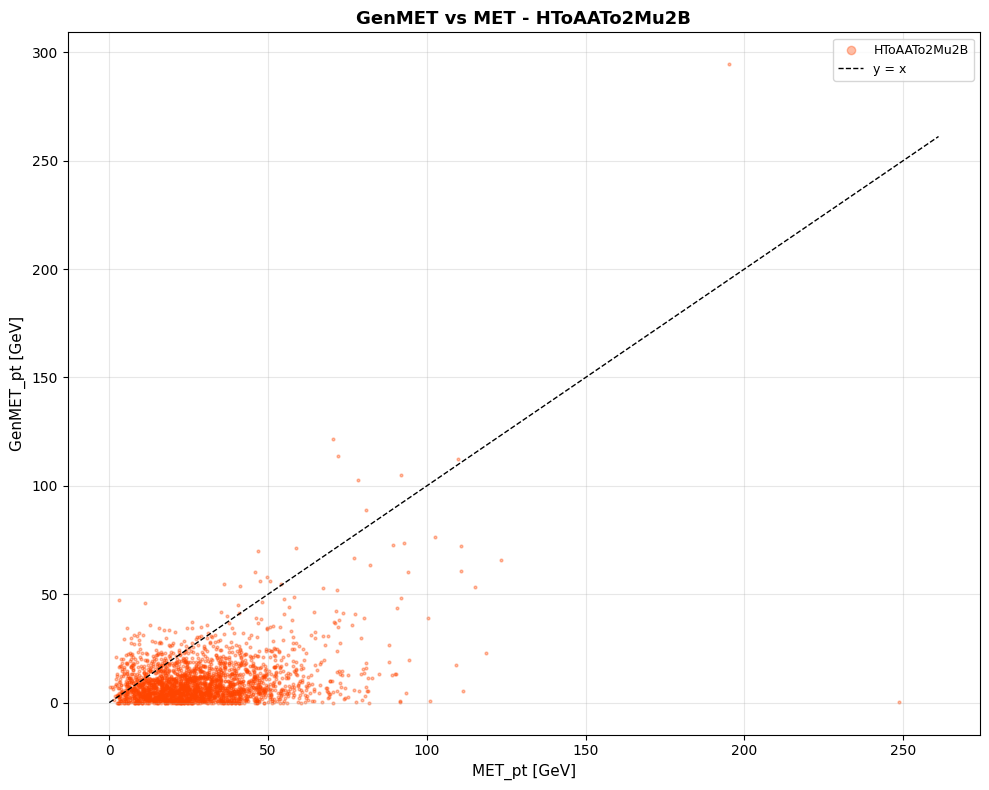

In [142]:
_scatterplot_MET(df, label, color)

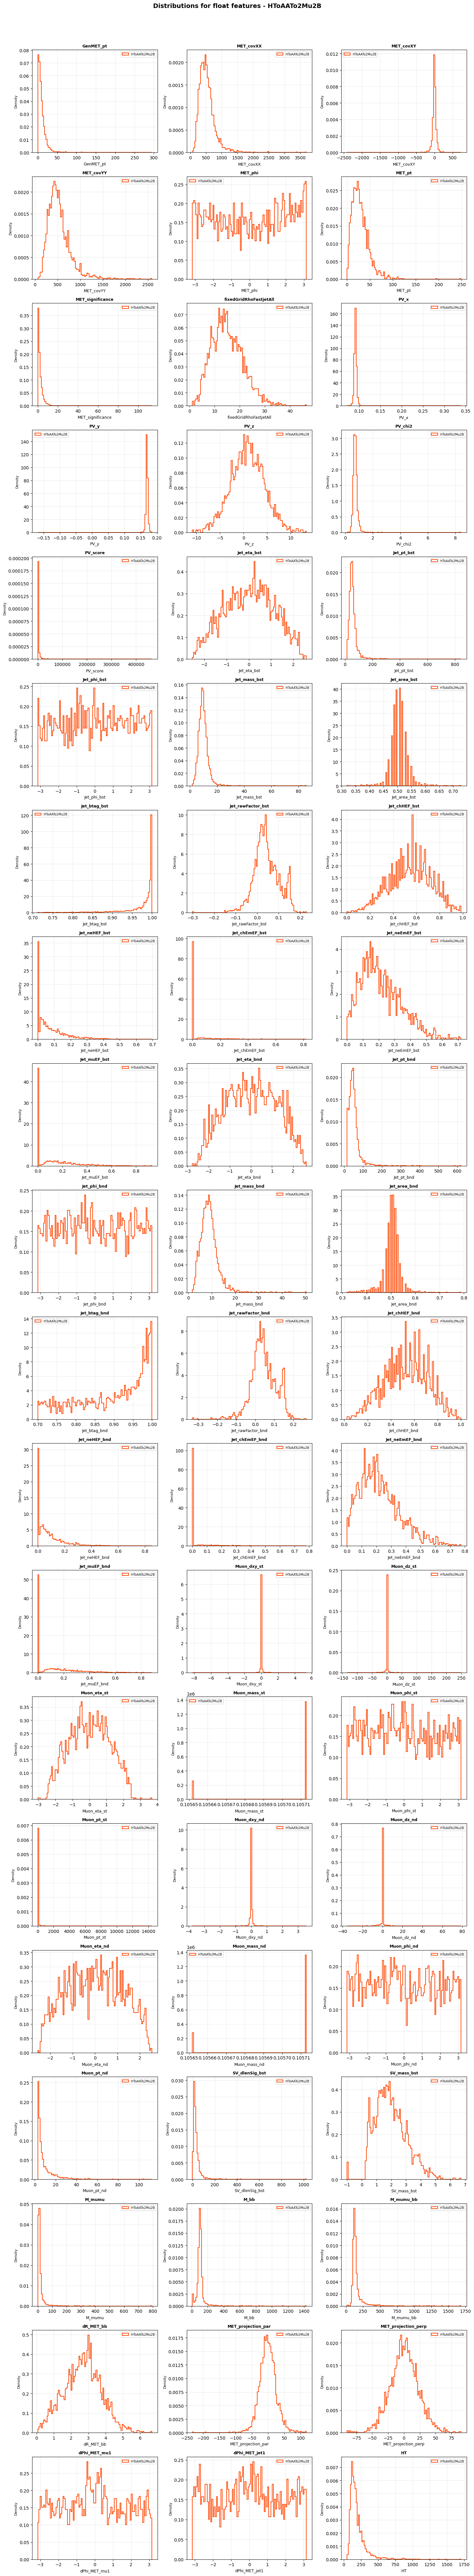

In [143]:
_data_distributions(df, FLOAT_FEATURES_HToAATo2Mu2B, label, color)

Outliers — HToAATo2Mu2B
  GenMET_pt               127 outliers (5.02%)
  MET_covXX                86 outliers (3.40%)
  MET_covXY               233 outliers (9.21%)
  MET_covYY               100 outliers (3.95%)
  MET_phi                   0 outliers (0.00%)
  MET_pt                   74 outliers (2.92%)
  MET_significance        148 outliers (5.85%)
  fixedGridRhoFastjetAll     20 outliers (0.79%)
  PV_x                    120 outliers (4.74%)
  PV_y                    128 outliers (5.06%)
  PV_z                     26 outliers (1.03%)
  PV_chi2                  94 outliers (3.72%)
  PV_score                247 outliers (9.76%)
  Jet_eta_bst               0 outliers (0.00%)
  Jet_pt_bst              146 outliers (5.77%)
  Jet_phi_bst               0 outliers (0.00%)
  Jet_mass_bst             62 outliers (2.45%)
  Jet_area_bst            113 outliers (4.47%)
  Jet_btag_bst            281 outliers (11.11%)
  Jet_rawFactor_bst        28 outliers (1.11%)
  Jet_chHEF_bst             4 out

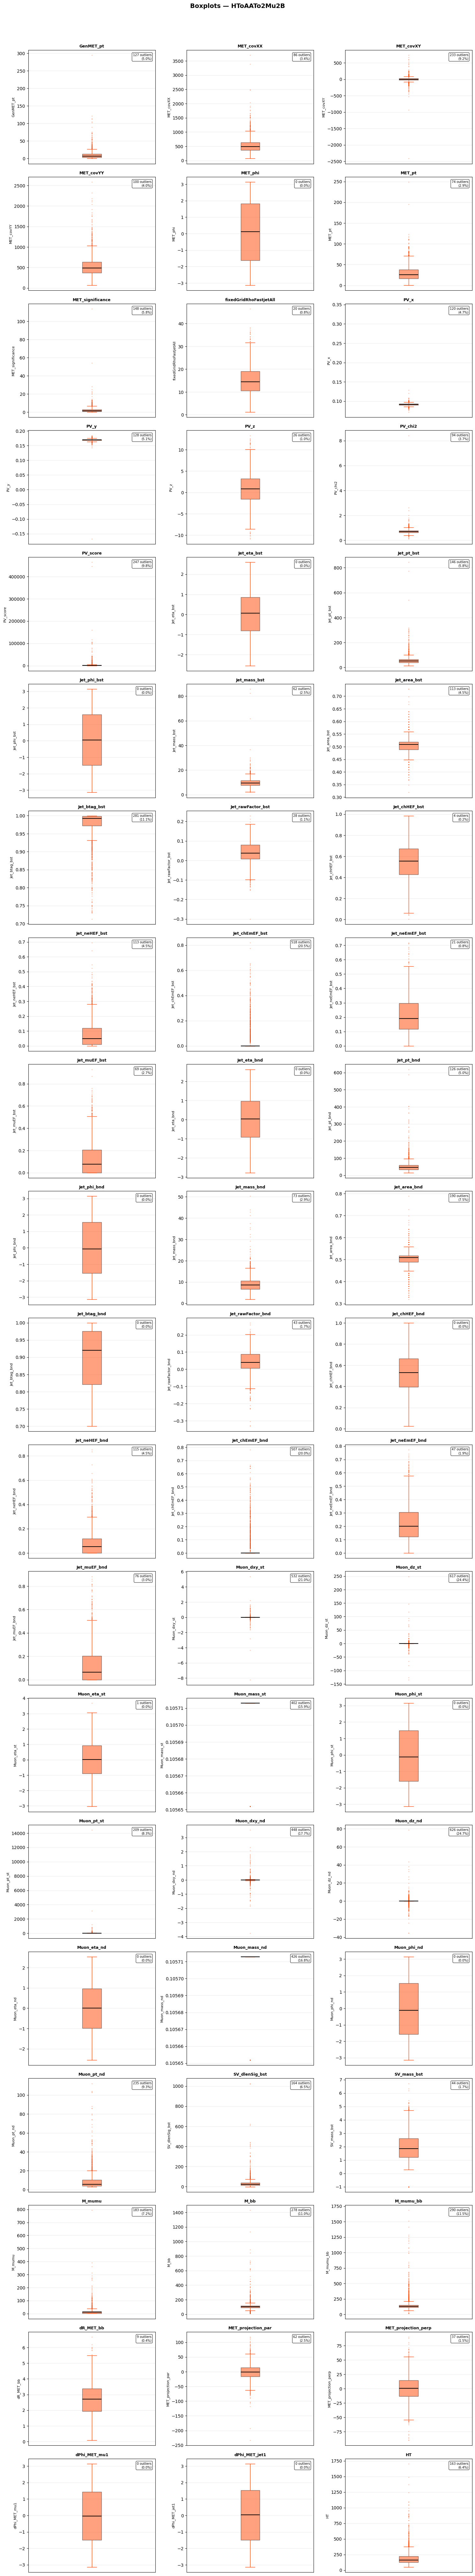

In [144]:
_boxplots(df, FLOAT_FEATURES_HToAATo2Mu2B, label, color)

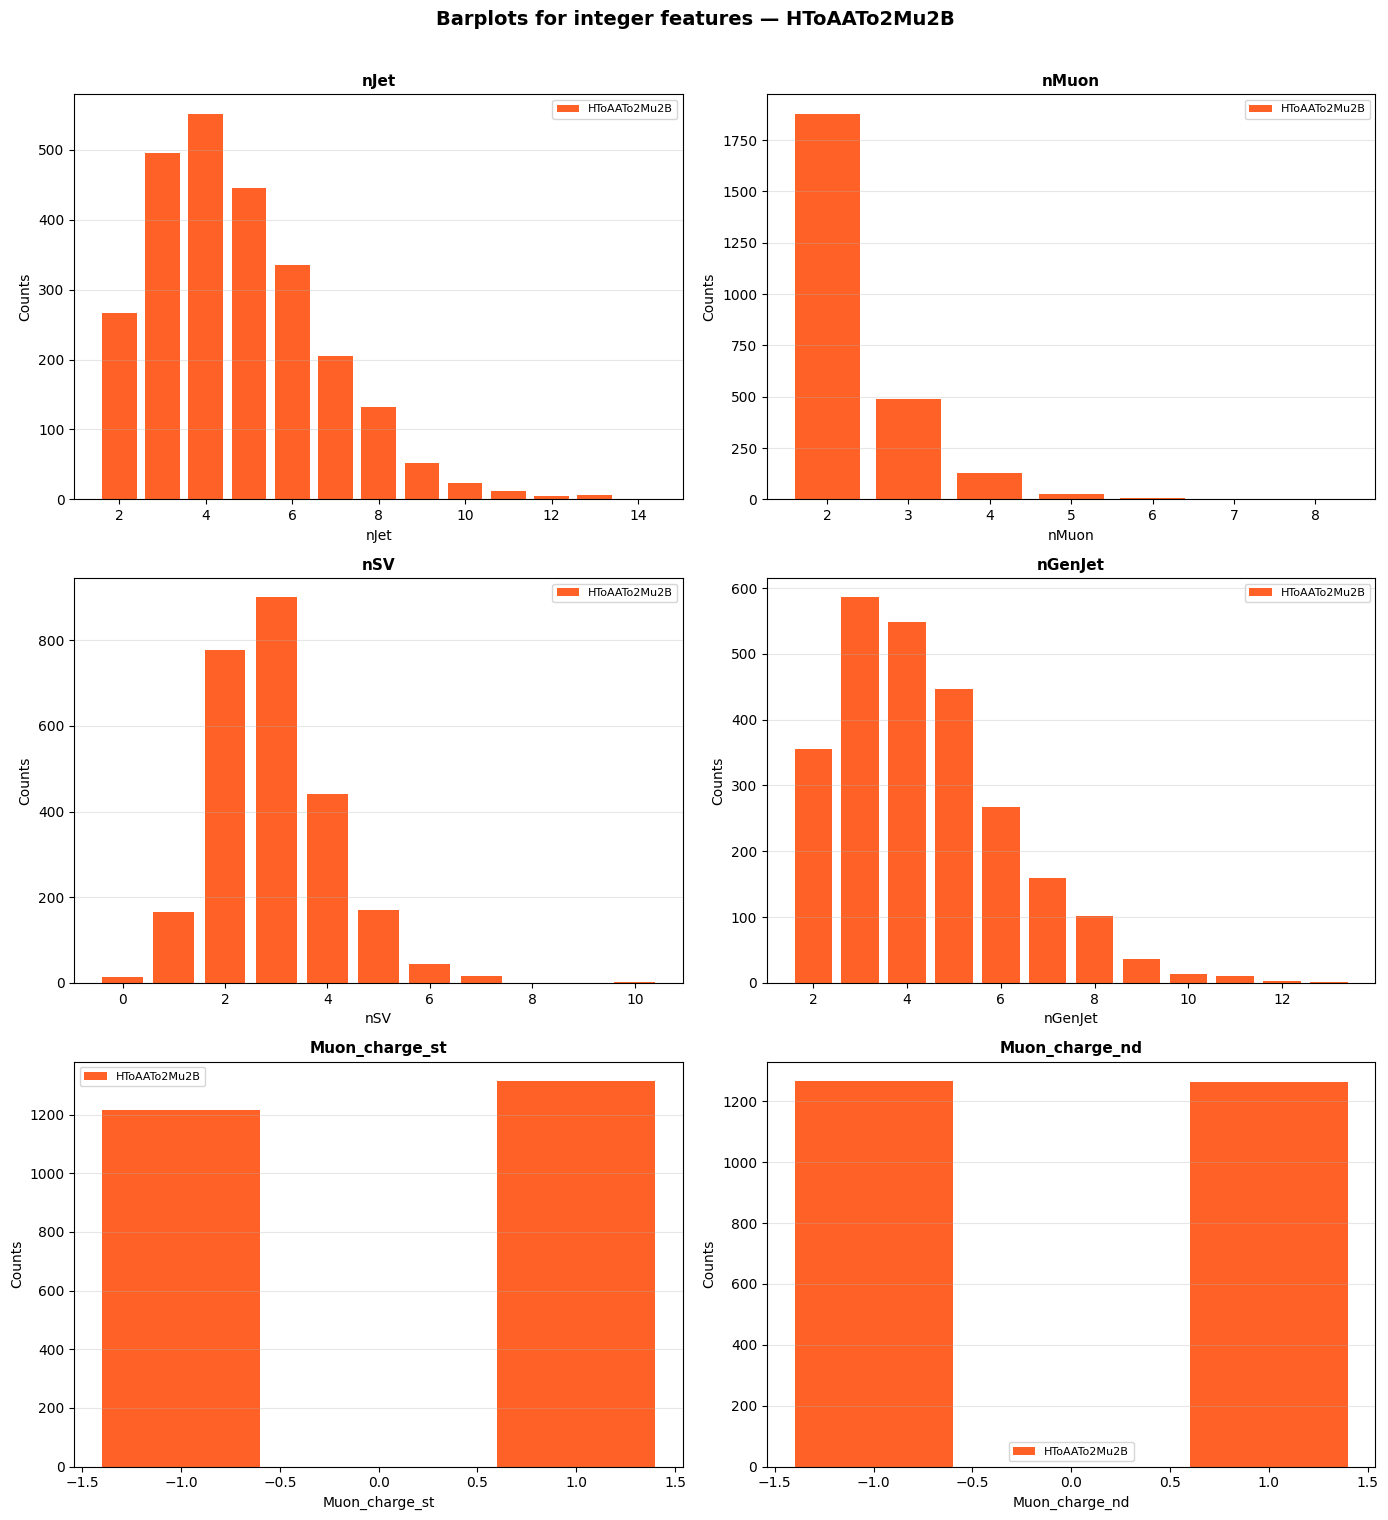

In [145]:
_data_barplots(df, INT_FEATURES_HToAATo2Mu2B, label, color)

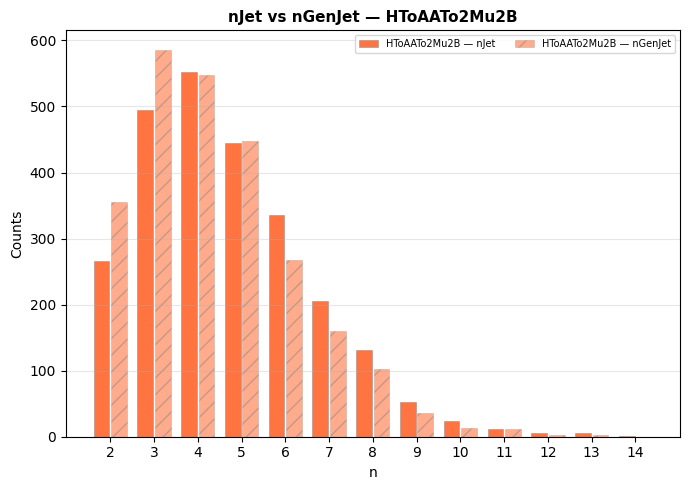

In [146]:
_nJet_vs_nGenJet(df, label, color)

Removing features that have no use for our purpose, that we have introduced just for analysis

In [147]:
DROP_HToAATo2Mu2B = [
    "nGenJet",
    "PV_x", "PV_y",
    "MET_phi", "MET_covYY",
    "Muon_mass_st", "Muon_mass_nd",
    "Jet_mass_bst", "Jet_mass_bnd",
    "Jet_chEmEF_bst", "Jet_chEmEF_bnd",
    "Jet_neEmEF_bst", "Jet_neEmEF_bnd",
    "Jet_muEF_bst", "Jet_muEF_bnd",
    "Jet_pt_bst", "Jet_pt_bnd",
    "Jet_area_bst", "Jet_area_bnd",
    "Muon_dxy_st", "Muon_dxy_nd",
    "Muon_dz_st", "Muon_dz_nd"
]

df = df.drop(columns=DROP_HToAATo2Mu2B)
print(f"Shape of HToAATo2Mu2B after preparation: {df.shape[1]} features x {df.shape[0]} events")
print(f"Remaining features of HToAATo2Mu2B after preparation: {list(df.columns)}")

df.to_parquet("../CleanedDatasets/HToAATo2Mu2B.parquet", index=False)

Shape of HToAATo2Mu2B after preparation: 43 features x 2530 events
Remaining features of HToAATo2Mu2B after preparation: ['GenMET_pt', 'MET_covXX', 'MET_covXY', 'MET_pt', 'MET_significance', 'fixedGridRhoFastjetAll', 'PV_z', 'PV_chi2', 'PV_score', 'Jet_eta_bst', 'Jet_phi_bst', 'Jet_btag_bst', 'Jet_rawFactor_bst', 'Jet_chHEF_bst', 'Jet_neHEF_bst', 'Jet_eta_bnd', 'Jet_phi_bnd', 'Jet_btag_bnd', 'Jet_rawFactor_bnd', 'Jet_chHEF_bnd', 'Jet_neHEF_bnd', 'Muon_eta_st', 'Muon_phi_st', 'Muon_pt_st', 'Muon_eta_nd', 'Muon_phi_nd', 'Muon_pt_nd', 'SV_dlenSig_bst', 'SV_mass_bst', 'M_mumu', 'M_bb', 'M_mumu_bb', 'dR_MET_bb', 'MET_projection_par', 'MET_projection_perp', 'dPhi_MET_mu1', 'dPhi_MET_jet1', 'HT', 'nJet', 'nMuon', 'nSV', 'Muon_charge_st', 'Muon_charge_nd']
